In [18]:
from datasets import load_dataset
import pandas as pd

# Load the unsplit dataset
ds = load_dataset("dair-ai/emotion", "unsplit")

# Access the full data (stored in the 'train' key)
full_data = ds["train"]

# Convert to Pandas DataFrame
df = full_data.to_pandas()

# Optional: Map integer labels to emotion names for clarity
label_map = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}
df['label_name'] = df['label'].map(label_map)

# Save to CSV
df.to_csv("emotion_dataset_full.csv", index=False)

print("Dataset saved to 'emotion_dataset_full.csv'")

Dataset saved to 'emotion_dataset_full.csv'


In [20]:
import pandas as pd

df = pd.read_csv("emotion_data_full_.csv")

In [21]:
df

,Unnamed: 0,text,label_name
0,0,i feel awful about it too because it s my job ...,sadness
1,1,im alone i feel awful,sadness
2,2,ive probably mentioned this before but i reall...,joy
3,3,i was feeling a little low few days back,sadness
4,4,i beleive that i am much more sensitive to oth...,love
...,...,...,...
416804,416804,that was what i felt when i was finally accept...,joy
416805,416805,i take every day as it comes i m just focussin...,fear
416806,416806,i just suddenly feel that everything was fake,sadness
416807,416807,im feeling more eager than ever to claw back w...,joy


In [22]:
df.shape

(416809, 3)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  416809 non-null  int64 
 1   text        416809 non-null  object
 2   label_name  416809 non-null  object
dtypes: int64(1), object(2)
memory usage: 9.5+ MB


In [25]:
df.describe(include='object')

,text,label_name
count,416809,416809
unique,393822,6
top,i feel more adventurous willing to take risks,joy
freq,16,141067


In [26]:
df.isnull().sum()

,0
Unnamed: 0,0
text,0
label_name,0


In [27]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [ ]:
# EDA

In [28]:
df['label_name'].value_counts()

,count
label_name,
joy,141067
sadness,121187
anger,57317
fear,47712
love,34554
surprise,14972


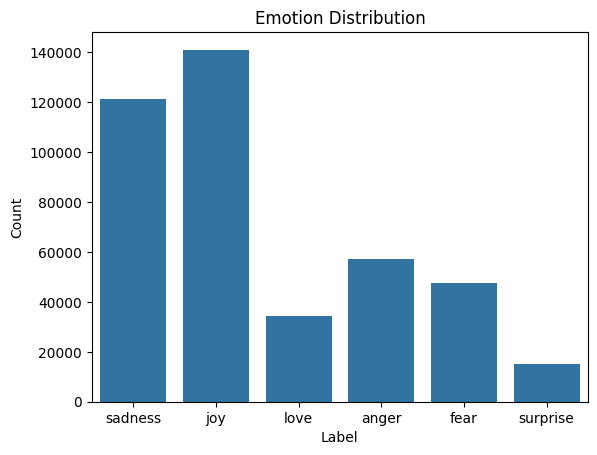

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='label_name')
plt.title('Emotion Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [33]:
# The datasets is imbalanced..
df['length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df.head()

,Unnamed: 0,text,label_name,length,word_count
0,0,i feel awful about it too because it s my job ...,sadness,112,26
1,1,im alone i feel awful,sadness,21,5
2,2,ive probably mentioned this before but i reall...,joy,152,27
3,3,i was feeling a little low few days back,sadness,40,9
4,4,i beleive that i am much more sensitive to oth...,love,99,18


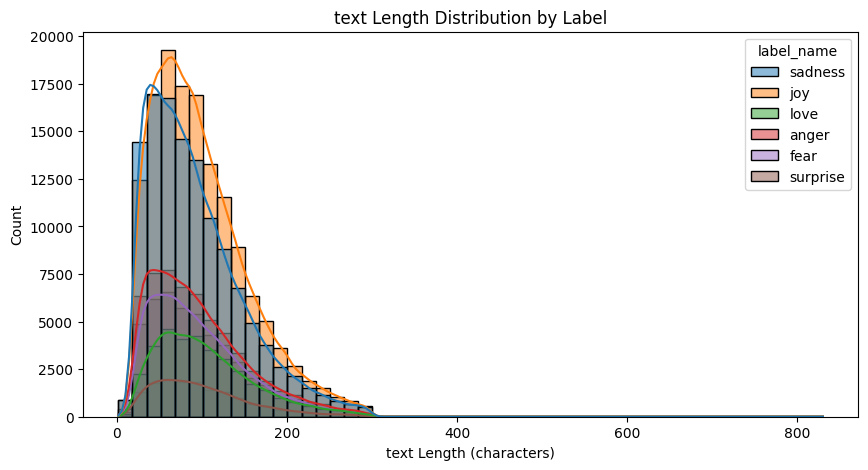

In [34]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='length', hue='label_name', bins=50, kde=True)
plt.title('text Length Distribution by Label')
plt.xlabel('text Length (characters)')
plt.show()

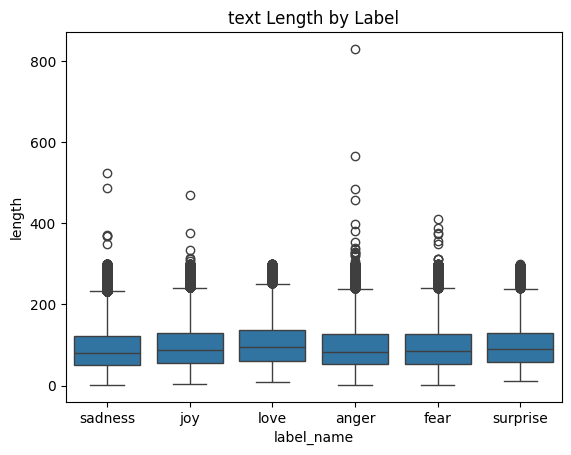

In [35]:
sns.boxplot(data=df, x='label_name', y='length')
plt.title('text Length by Label')
plt.show()

In [37]:
# Splitting the data for training

from sklearn.model_selection import train_test_split

X = df['text']
y = df['label_name']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=1,
                                                    stratify=y)

print('the shape of the train data set is : ', X_train.shape)
print('the shape of the test data set is : ', X_test.shape)

the shape of the train data set is :  (291766,)
the shape of the test data set is :  (125043,)


In [38]:
from sklearn.feature_extraction.text import CountVectorizer

# Create CountVectorizer
cv = CountVectorizer()

# Fit on training data and transform
X_train_cv = cv.fit_transform(X_train)

# Transform test data
X_test_cv = cv.transform(X_test)

print("X_train shape:", X_train_cv.shape)
print("X_test shape:", X_test_cv.shape)

X_train shape: (291766, 63555)
X_test shape: (125043, 63555)


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Create CountVectorizer
cv = CountVectorizer()

# Fit on training data and transform
# Learns the vocabulary from the training data.
# Converts the training text into numerical features.
X_train_cv = cv.fit_transform(X_train)

# Transform test data
# Uses the same vocabulary learned from the training data.
# Converts the test text into numerical features.
# Do not use fit_transform() on the test data, as it would create a different vocabulary and cause data leakage.
X_test_cv = cv.transform(X_test)

print("X_train shape:", X_train_cv.shape)
print("X_test shape:", X_test_cv.shape)

In [39]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english')
X_train = cv.fit_transform(X_train)
X_test = cv.transform(X_test)

print('Vocabulary size :', len(cv.vocabulary_))
print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)

Vocabulary size : 63243
X_train shape: (291766, 63243)
X_test shape : (125043, 63243)


In [ ]:
# Naive Bayes Classifier
# Naive Bayes is a probabilistic classifier based on Bayes'
#  Theorem with a "naive" assumption that all features are independent of each other.

In [41]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [42]:
for actual, pred in list(zip(y_test[:10], y_pred[:10])):
    print(f'Actual: {actual:5s} | Predicted: {pred}')

Actual: joy   | Predicted: joy
Actual: sadness | Predicted: sadness
Actual: anger | Predicted: anger
Actual: sadness | Predicted: sadness
Actual: sadness | Predicted: sadness
Actual: joy   | Predicted: anger
Actual: joy   | Predicted: joy
Actual: sadness | Predicted: sadness
Actual: fear  | Predicted: fear
Actual: sadness | Predicted: sadness


In [43]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8614


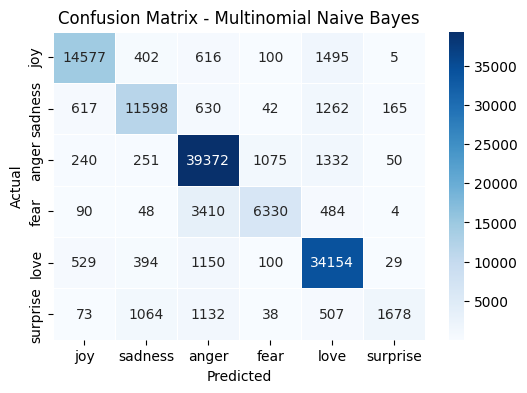

In [44]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['joy','sadness','anger','fear','love','surprise'],
            yticklabels=['joy','sadness','anger','fear','love','surprise'],
            linewidths=0.5)
plt.title('Confusion Matrix - Multinomial Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [45]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['joy','sadness','anger','fear','love','surprise']))

              precision    recall  f1-score   support

         joy       0.90      0.85      0.87     17195
     sadness       0.84      0.81      0.83     14314
       anger       0.85      0.93      0.89     42320
        fear       0.82      0.61      0.70     10366
        love       0.87      0.94      0.90     36356
    surprise       0.87      0.37      0.52      4492

    accuracy                           0.86    125043
   macro avg       0.86      0.75      0.79    125043
weighted avg       0.86      0.86      0.86    125043



In [46]:
import gradio as gr

# Prediction function
def predict_emotion(text):
    text_vec = cv.transform([text])      # Convert text to vector
    prediction = model.predict(text_vec) # Predict emotion
    return prediction[0]

# Gradio Interface
demo = gr.Interface(
    fn=predict_emotion,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter your text here..."
    ),
    outputs=gr.Textbox(label="Predicted Emotion"),
    title="Emotion Detection App",
    description="Enter a sentence to predict its emotion."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f8f27455a271689951.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
